# 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import calendar
import ipywidgets as widgets
from ipywidgets import interact

from statsmodels.stats.outliers_influence import variance_inflation_factor

import os

# 2. Load Dataset

In [2]:
df_train = pd.read_excel("../Dataset/training.xlsx")
df_test = pd.read_excel("../Dataset/testing.xlsx")

In [3]:
df_train.head()

,Year,Month,Day,Hour,Load,Site-1 Temp,Site-2 Temp,Site-3 Temp,Site-4 Temp,Site-5 Temp,Site-1 GHI,Site-2 GHI,Site-3 GHI,Site-4 GHI,Site-5 GHI
0,1,1,1,1,1997,8.0,8.2,5.3,9.4,8.1,0,0,0,0,0
1,1,1,1,2,1921,8.3,8.6,5.2,8.6,7.1,0,0,0,0,0
2,1,1,1,3,1861,8.1,8.8,5.1,8.7,6.2,0,0,0,0,0
3,1,1,1,4,1833,7.6,8.1,4.3,8.5,6.0,0,0,0,0,0
4,1,1,1,5,1847,7.3,7.5,4.0,8.6,6.9,0,0,0,0,0


In [4]:
df_test.head()

,Year,Month,Day,Hour,Load,Site-1 Temp,Site-2 Temp,Site-3 Temp,Site-4 Temp,Site-5 Temp,Site-1 GHI,Site-2 GHI,Site-3 GHI,Site-4 GHI,Site-5 GHI
0,3,1,1,1,NaN,12.3,11.5,9.3,12.7,10.8,0,0,0,0,0
1,3,1,1,2,NaN,12.1,11.1,9.3,12.3,10.6,0,0,0,0,0
2,3,1,1,3,NaN,10.8,10.2,9.0,11.8,9.9,0,0,0,0,0
3,3,1,1,4,NaN,10.0,10.3,9.3,10.9,8.9,0,0,0,0,0
4,3,1,1,5,NaN,11.1,10.3,9.8,10.9,9.6,0,0,0,0,0


# 3. Data Overview

In [5]:
load_col = ['Load']
temp_cols = [temp for temp in df_train.columns if 'Temp' in temp]
ghi_cols = [ghi for ghi in df_train.columns if 'GHI' in ghi]
all_cols = load_col + temp_cols + ghi_cols

stats_lst = []

for year in df_train['Year'].unique():
    year_df = df_train[df_train['Year'] == year]

    stats = {
        'Mean': year_df[all_cols].mean(),
        'Variance': year_df[all_cols].var(),
        'Median': year_df[all_cols].median(),
        'Min': year_df[all_cols].min(),
        'Max': year_df[all_cols].max(),
        'Skewness': year_df[all_cols].skew(),
        'Kurtosis': year_df[all_cols].kurtosis()
    }

    stats_df = pd.DataFrame(stats).T
    stats_df['Year'] = year
    stats_df = stats_df.set_index('Year', append = True).reorder_levels([1, 0])
    stats_lst.append(stats_df)

summary_stats = pd.concat(stats_lst)
summary_stats.columns = pd.MultiIndex.from_tuples([
    ('Load', ''),
    ('Temperature', 'Site 1'),
    ('Temperature', 'Site 2'),
    ('Temperature', 'Site 3'),
    ('Temperature', 'Site 4'),
    ('Temperature', 'Site 5'),
    ('GHI', 'Site 1'),
    ('GHI', 'Site 2'),
    ('GHI', 'Site 3'),
    ('GHI', 'Site 4'),
    ('GHI', 'Site 5')
]) 

display(summary_stats.style.format('{:.2f}'))

### 1. Load Demand

- **Yearly Trend:** The average load remains relatively stable across the two years (~2,162 MW in Year 1 vs. ~2,145 MW in Year 2). However, the variance in Year 1 is significantly higher (216,944 vs. 165,227), as reflected by the Peak Load reaching **4,397 MW** in Year 1, compared to only **3,808 MW** in Year 2.
- **Distribution Shape:**
  - **Skewness > 0** (1.18 in Year 1 and 0.67 in Year 2) and **Kurtosis > 0** (2.10 in Year 1 and 0.84 in Year 2): The load distribution is clearly right-skewed and exhibits heavy tails.
  - *Interpretation:* Electricity demand is primarily concentrated around the average level (~2,000–2,100 MW), but occasional extreme spikes in demand occur with relatively low frequency.

### 2. Temperature (Site 1 to Site 5)

- **Spatial Homogeneity:**
  - The average temperatures across the five sites are highly similar, ranging from approximately **16.5°C to 18.3°C**.
  - **Site 3 is the most anomalous site (Outlier Site):** It exhibits the widest range of extreme temperatures (Min as low as -0.5°C in Year 1 and Max as high as 43.0°C in Year 1) and the highest variance (~49–54). The other sites (Site 1, 2, 4, and 5) show much smoother variations, with variances ranging from approximately ~18–34.
- **Distribution Shape:**
  - **Skewness close to 0** (-0.02 to 0.45) and **negative Kurtosis** (-0.45 to 0.02): Temperature approximately follows a normal or slightly flat (platykurtic) distribution, without the heavy tails observed in the Load distribution.

### 3. Solar Radiation (GHI - Global Horizontal Irradiance)

- **High Spatial Homogeneity:**
  - All five sites have highly similar mean values (~218–228 W/m²), maximum values (~1,024–1,049 W/m²), and standard deviations.
- **Distribution Characteristics Due to Nighttime Data:**
  - **Median = 11–12 W/m²** and **Min = 0:** Due to the day/night cycle (GHI = 0 during nighttime), the median is pulled down close to zero.
  - **Skewness > 1** (~1.07–1.12): The distribution is strongly right-skewed because irradiance remains very low for most of the day (during nighttime, early morning, and late afternoon), with a sharp increase occurring only during a few hours around midday.

### 4. Data Stability Across the Two Years (Data Drift)

- **GHI and Temperature:** The Mean, Median, Skewness, and Kurtosis values of GHI and Temperature are nearly identical between Year 1 and Year 2. This indicates that there is **no severe Covariate Shift** in the weather-related variables.
- **Load:** There is a decrease in variability in Year 2 (with a lower Peak Load). If Year 1 is used as the Training Set and Year 2 as the Validation Set, it is important to note that the model trained on Year 1 may become overly sensitive to extreme peak values (**overfitting to peaks**).

### 5. Actionable Insights for Modeling

1. **Weather Data Dimensionality Reduction:**
   - Since the five GHI and Temperature sites (except for Site 3) exhibit highly similar statistical characteristics, **Multicollinearity** is likely to occur. **PLS (Partial Least Squares)** or **PCA** should be considered to compress these five sites into 1–2 principal factors.

2. **Handling Site 3:**
   - The extreme values observed at Site 3 (-0.5°C and 43°C) should be investigated to determine whether they reflect actual microclimatic conditions or **sensor noise** before being incorporated into the model.

3. **Load Target Transformation:**
   - Since `Load` exhibits relatively high Skewness and Kurtosis in Year 1, applying a Log transformation (`np.log1p`) or Box-Cox transformation could be considered to improve the stability of linear models and Neural Networks during training.

# 4. Load Analyzing

## 4.1 Monthly Load

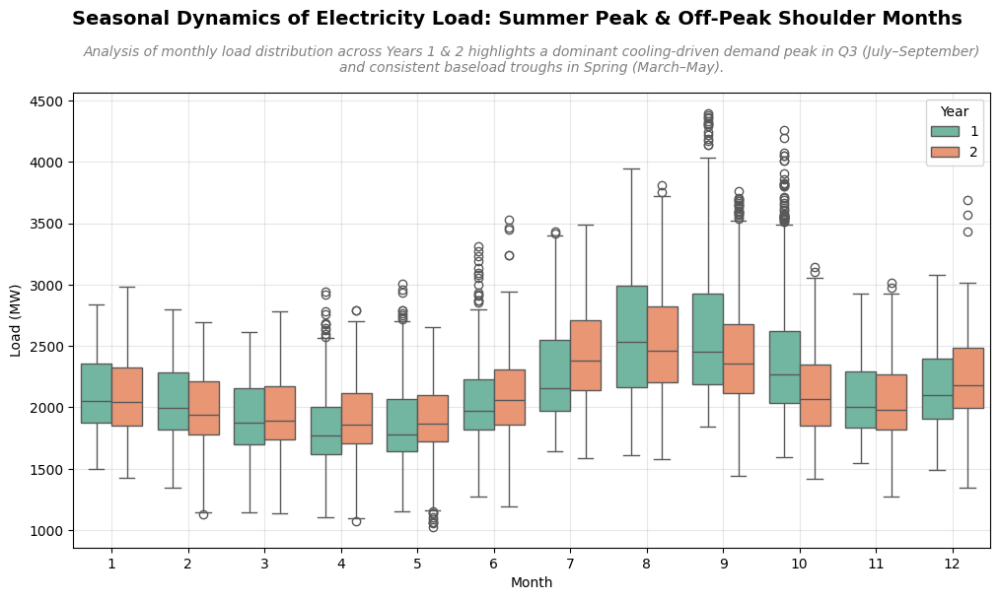

In [6]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_train, x='Month', y='Load', hue='Year', palette='Set2')

plt.suptitle(
    'Seasonal Dynamics of Electricity Load: Summer Peak & Off-Peak Shoulder Months',
    fontsize=14,
    fontweight='bold',
    y=1.02
)

plt.title(
    'Analysis of monthly load distribution across Years 1 & 2 highlights a dominant cooling-driven demand peak in Q3 (July–September)\nand consistent baseload troughs in Spring (March–May).',
    fontsize=10,
    fontstyle='italic',
    color='gray',
    pad=15
)

plt.xlabel('Month')
plt.ylabel('Load (MW)')
plt.grid(True, alpha=0.3)

plt.show()

- **Bimodal Seasonal Pattern:**
  - **Summer Load Peak (Q3):** Electricity demand reaches its peak from **June to September**, with July–September showing the highest median load (~2,200–2,600 MW). This is a direct consequence of increased cooling demand (HVAC / air conditioning) as ambient temperatures rise.
  - **Winter Load Peak (Q4/Q1):** Electricity demand increases slightly again during **December–January** (~2,000–2,200 MW), driven by heating and prolonged lighting demand.

- **Shoulder Months & Load Troughs:**
  - **March to May** (and October–November) serve as shoulder months with relatively mild weather conditions. Electricity demand reaches its lowest levels during these periods, with the median load in April dropping below 1,800 MW.

- **Peak Outliers & Extreme Demand:**
  - From **August to October**, numerous outliers appear above the upper whisker, reaching historical peak values between **3,500 and 4,400 MW** (particularly in Year 1). This indicates that the risk of grid overloading is primarily concentrated in late summer and early autumn.

- **Year-over-Year Stability:**
  - The seasonal variation patterns between **Year 1 and Year 2 are highly consistent**, confirming strong seasonal stability and providing an important signal for applying techniques such as **Fourier Terms** or **Seasonal Features** in forecasting models.

## 4.2 Weekly Load

In [10]:
# --- Create mappings for month-day calculations ---
days_in_month = {
    1: 31, 2: 28, 3: 31, 4: 30, 5: 31, 6: 30,
    7: 31, 8: 31, 9: 30, 10: 31, 11: 30, 12: 31
}
cumulative_days_map = {i: sum(list(days_in_month.values())[:i-1]) for i in range(1, 13)}

def add_week_info(df):
    df = df.copy()
    
    df.dropna(subset=['Month', 'Day'], inplace=True)
    df['Month'] = df['Month'].astype(int)
    df['Day'] = df['Day'].astype(int)

    max_days = df['Month'].map(days_in_month)
    df['Day_Clipped'] = np.minimum(df['Day'], max_days)
    cumulative_days = df['Month'].map(cumulative_days_map)
    df['DayOfYear'] = cumulative_days + df['Day_Clipped']

    df['WeekOfYear'] = ((df['DayOfYear'] - 1) // 7) + 1
    df['DayOfWeek'] = (df['DayOfYear'] - 1) % 7
    
    return df

# --- Prepare the training dataframe ---
df_train = add_week_info(df_train)
print("Weekly information has been added to the dataframe successfully.")

Weekly information has been added to the dataframe successfully.


In [11]:
def plot_weekly_load_comparison(month):
    fig, axes = plt.subplots(1, 2, figsize=(18, 8), sharey=True)
    
    for idx, year in enumerate([1, 2]):
        ax = axes[idx]
        
        # Filter for the selected year and month
        month_df = df_train[(df_train["Year"] == year) & (df_train["Month"] == month)]
        
        # Create the 'HourOfWeek' column for a continuous x-axis
        month_df = month_df.copy()
        month_df['HourOfWeek'] = month_df['DayOfWeek'] * 24 + month_df['Hour']
        
        # Find all the unique weeks within that month
        weeks_in_month = month_df['WeekOfYear'].unique()
        
        # Plot each individual week's pattern with transparency
        for week in weeks_in_month:
            week_subset = month_df[month_df['WeekOfYear'] == week]
            ax.plot(week_subset['HourOfWeek'], week_subset['Load'], alpha=0.3, linestyle="-")
            
        # Calculate and plot the centroid (average weekly pattern for the month)
        centroid = month_df.groupby('HourOfWeek')['Load'].mean()
        ax.plot(centroid.index, centroid, color='black', lw=2.5, linestyle='-', label="Monthly Centroid")
        
        # --- Formatting the plot ---
        ax.set_xlabel("Hour of the Week")
        ax.set_title(f"Weekly Load Variation in {calendar.month_name[month]} (Year {year})")
        ax.legend(loc="upper left")
        ax.grid(True, linestyle='--', alpha=0.6)
        
        # Set x-ticks to correspond to the start of each day for readability
        tick_locations = [i * 24 for i in range(7)]
        tick_labels = ['Mon', 'Tues', 'Wed', 'Thurs', 'Fri', 'Sat', 'Sun']
        ax.set_xticks(tick_locations)
        ax.set_xticklabels(tick_labels)
        ax.set_xlim(0, 168)

    axes[0].set_ylabel("Electricity Load")
    plt.tight_layout()
    plt.show()

# --- Widgets for the Load plot (only month is needed) ---
month_widget_load = widgets.Dropdown(options={calendar.month_name[m]: m for m in sorted(df_train["Month"].unique()) if m != 0}, value=4, description="Month:")

interact(plot_weekly_load_comparison, month=month_widget_load)

interactive(children=(Dropdown(description='Month:', index=3, options={'January': np.int64(1), 'February': np.…

<function __main__.plot_weekly_load_comparison(month)>

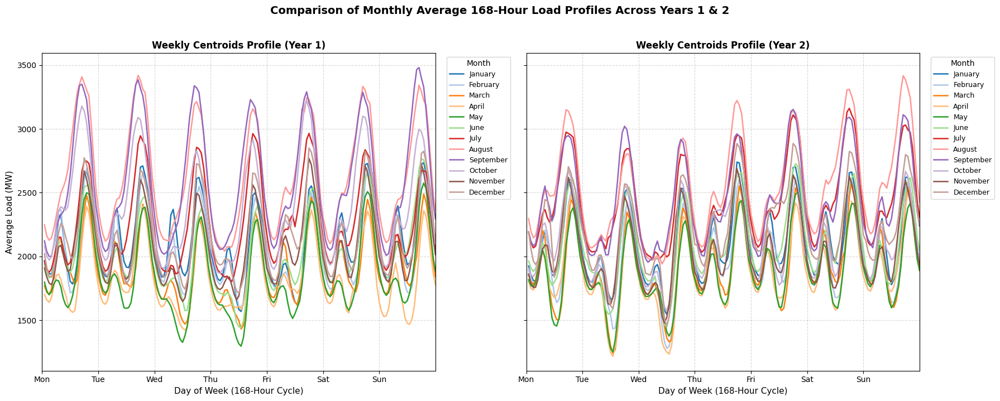

In [12]:
# 1. Tính toán HourOfWeek (0–167) và lấy trung bình phụ tải theo từng Tháng & Năm
df_plot_weekly = df_train.copy()
df_plot_weekly['HourOfWeek'] = df_plot_weekly['DayOfWeek'] * 24 + df_plot_weekly['Hour']

# Groupby để tìm Centroid (đường trung bình 168 giờ) cho từng tháng của mỗi năm
monthly_centroids = (
    df_plot_weekly.groupby(['Year', 'Month', 'HourOfWeek'])['Load']
    .mean()
    .reset_index()
)

# 2. Khởi tạo biểu đồ 2 subplots cho Year 1 và Year 2
fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=True)

# Bảng màu 12 sắc thái để phân biệt 12 tháng
colors = plt.cm.tab20(range(12))

for idx, year in enumerate([1, 2]):
    ax = axes[idx]
    year_data = monthly_centroids[monthly_centroids['Year'] == year]
    
    # Vẽ đường trung bình tuần của từng tháng
    for month in sorted(year_data['Month'].unique()):
        month_data = year_data[year_data['Month'] == month]
        ax.plot(
            month_data['HourOfWeek'], 
            month_data['Load'], 
            label=calendar.month_name[month],
            linewidth=1.8,
            color=colors[month - 1]
        )
    
    # Cấu hình trục X tương ứng với 7 ngày trong tuần
    tick_locations = [i * 24 for i in range(7)]
    tick_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
    ax.set_xticks(tick_locations)
    ax.set_xticklabels(tick_labels)
    ax.set_xlim(0, 168)
    
    ax.set_xlabel("Day of Week (168-Hour Cycle)", fontsize=11)
    ax.set_title(f"Weekly Centroids Profile (Year {year})", fontsize=12, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(title="Month", bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)

# Cấu hình tiêu đề tổng thể
fig.suptitle(
    "Comparison of Monthly Average 168-Hour Load Profiles Across Years 1 & 2", 
    fontsize=14, 
    fontweight='bold', 
    y=1.02
)
axes[0].set_ylabel("Average Load (MW)", fontsize=11)

plt.tight_layout()
plt.show()

- **High Temporal Consistency:** All seven days of the week exhibit a similar bimodal load pattern, indicating a highly consistent weekly cycle.
- **Weekend Behavior (Sat–Sun):** Weekend peak loads tend to decrease slightly during some transitional months. However, during the summer peak months (August–September), Sunday load remains exceptionally high (reaching 3,300–3,500 MW), reflecting sustained residential demand despite reduced office and workplace activity.

**Year 1 vs. Year 2 Comparison (YoY Comparison)**

- **Structural Stability:** The load profiles between Year 1 and Year 2 are highly consistent in terms of peak/trough timing and the overall pattern of load increases and decreases, confirming a strong and stable temporal periodicity.
- **Peak Load Compression in Year 2:**
  - In Year 1, the average peak load during the high-demand months (August–September) reaches approximately **~3,350 MW** in the 24-hour profile and **~3,500 MW** in the 168-hour profile.
  - In Year 2, the peaks for these months decrease slightly to approximately **~3,100–3,150 MW**, suggesting either a reduction in peak demand or less extreme summer weather conditions in Year 2 compared with Year 1.

## 4.3 Daily Load

In [13]:
def plot_daily_load_widget(month):
    fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)
        
    for idx, year in enumerate([1, 2]):
        ax = axes[idx]
        
        # Lọc dữ liệu theo Năm và Tháng chọn
        month_df = df_train[(df_train["Year"] == year) & (df_train["Month"] == month)].copy()
        
        # Lấy danh sách các ngày duy nhất trong tháng đó
        days_in_month = month_df['Day'].unique()
        
        # 1. Vẽ đường phụ tải 24h của từng ngày riêng lẻ (đường mờ alpha=0.2)
        for day in days_in_month:
            day_subset = month_df[month_df['Day'] == day]
            ax.plot(day_subset['Hour'], day_subset['Load'], alpha=0.2, linestyle="-")
            
        # 2. Tính và vẽ đường Trung bình (Monthly Centroid) 24h của tháng đó
        centroid = month_df.groupby('Hour')['Load'].mean()
        ax.plot(centroid.index, centroid, color='black', lw=2.5, linestyle='-', label="Monthly Centroid")
        
        # --- Định dạng biểu đồ ---
        ax.set_xlabel("Hour of the Day (0–23h)", fontsize=11)
        ax.set_title(f"Daily Load Profile in {calendar.month_name[month]} (Year {year})", fontsize=12, fontweight='bold')
        ax.legend(loc="upper left")
        ax.grid(True, linestyle='--', alpha=0.5)
        
        # Định dạng trục X chạy từ 0 đến 23 giờ (bước giãn 2 tiếng)
        ax.set_xticks(range(0, 24, 2))
        ax.set_xlim(0, 23)

    axes[0].set_ylabel("Electricity Load (MW)", fontsize=11)
    plt.tight_layout()
    plt.show()

# --- Widget chọn tháng ---
month_widget_load = widgets.Dropdown(
    options={calendar.month_name[m]: m for m in sorted(df_train["Month"].unique()) if m != 0}, 
    value=4, 
    description="Month:"
)

# Khởi chạy tương tác với tên hàm trùng khớp
interact(plot_daily_load_widget, month=month_widget_load)

interactive(children=(Dropdown(description='Month:', index=3, options={'January': np.int64(1), 'February': np.…

<function __main__.plot_daily_load_widget(month)>

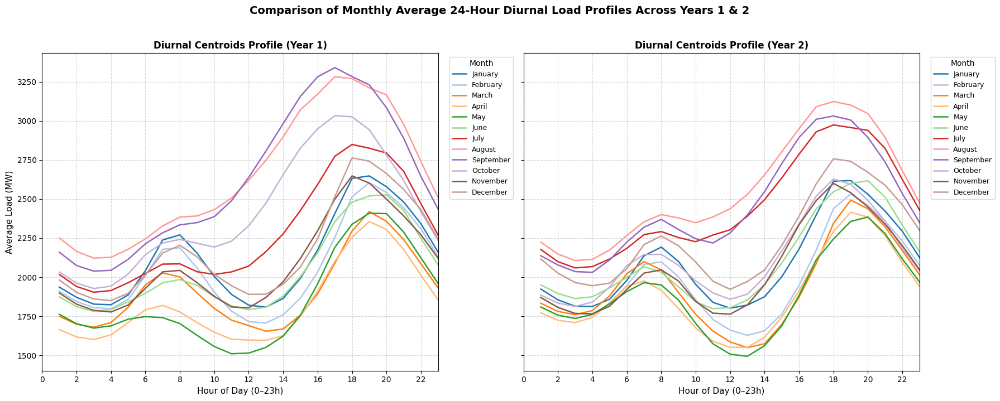

In [14]:
# 1. Tính trung bình phụ tải 24h theo từng Tháng & Năm
df_plot_daily = df_train.copy()
monthly_centroids = (
    df_plot_daily.groupby(['Year', 'Month', 'Hour'])['Load']
    .mean()
    .reset_index()
)

# 2. Khởi tạo biểu đồ 2 subplots cho Year 1 và Year 2
fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=True)

# Bảng màu 12 sắc thái để phân biệt 12 tháng
colors = plt.cm.tab20(range(12))

for idx, year in enumerate([1, 2]):
    ax = axes[idx]
    year_data = monthly_centroids[monthly_centroids['Year'] == year]
    
    # Vẽ đường trung bình 24h (diurnal centroid) của từng tháng
    for month in sorted(year_data['Month'].unique()):
        month_data = year_data[year_data['Month'] == month]
        ax.plot(
            month_data['Hour'], 
            month_data['Load'], 
            label=calendar.month_name[month],
            linewidth=1.8,
            color=colors[month - 1]
        )
    
    # Cấu hình trục X cho 24 giờ (từ 0 đến 23h, bước giãn 2 tiếng)
    ax.set_xticks(range(0, 24, 2))
    ax.set_xlim(0, 23)
    
    ax.set_xlabel("Hour of Day (0–23h)", fontsize=11)
    ax.set_title(f"Diurnal Centroids Profile (Year {year})", fontsize=12, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(title="Month", bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)

# Cấu hình tiêu đề tổng thể
fig.suptitle(
    "Comparison of Monthly Average 24-Hour Diurnal Load Profiles Across Years 1 & 2", 
    fontsize=14, 
    fontweight='bold', 
    y=1.02
)
axes[0].set_ylabel("Average Load (MW)", fontsize=11)

plt.tight_layout()
plt.show()

**Bimodal Profile with a Dominant Evening Peak:**
  - **Morning Peak (07:00–08:00):** The load increases rapidly from 04:00 and reaches a secondary peak around 07:00–08:00 (approximately 2,000–2,400 MW), as economic, industrial, and daily activities begin in the morning.
  - **Evening Peak (18:00–20:00):** The highest load of the day occurs between 18:00 and 20:00, reaching approximately 2,400–3,350 MW depending on the month. This period coincides with commuting hours, household activities (lighting and home appliances), and evening commercial services.

- **Nighttime Load Trough (03:00–04:00):** The lowest baseline load occurs around 03:00–04:00, falling to approximately 1,500–2,100 MW, when most industrial and residential activities are at their minimum.

- **Midday Dip (11:00–14:00):** A slight decline in load can be observed during the midday break in lower-load months. However, during the summer months, the peak period extends into the daytime, maintaining a relatively high load level.

**Monthly and Seasonal Shift**

- **Clear Differentiation Between Two Groups of Months:**
  - **High-Load Group (August, September, and October – upper purple/pink curves):** Peak loads exceed 3,000 MW. During these months, the daytime load range (10:00–16:00) expands significantly compared with nighttime levels, indicating a strong influence of cooling demand (air conditioning/HVAC) during periods of high temperature.
  - **Low-Load Group (March, April, and May – lower green/orange curves):** Peak loads remain around 2,300–2,400 MW. During the daytime, the load increases relatively slowly and rises sharply only during the evening peak.

- **Monthly Load Variation:** The difference between the highest-load month (September) and the lowest-load month (April) reaches approximately **900–1,000 MW** during peak hours.

# 5. GHI and Temperature Analyzing

## 5.1 Daily GHI for 2 years

In [15]:
def plot_daily_variation_ghi(month, site):
    fig, axes = plt.subplots(1, 2, figsize=(18, 9), sharey=True)
    for idx, year in enumerate([1, 2]):
        ax = axes[idx]
        filtered_df = df_train[(df_train["Year"] == year) & (df_train["Month"] == month)]
        for day in sorted(filtered_df["Day"].unique()):
            subset = filtered_df[filtered_df["Day"] == day]
            ax.plot(subset["Hour"], subset[site], alpha=0.5, linestyle="-", marker="o", lw=1.0)
        centroid = filtered_df.groupby("Hour")[site].mean()
        ax.plot(centroid.index, centroid, color='black', lw=2.5, marker='D', linestyle='-', label="Centroid")
        ax.set_xlabel("Hour of the Day")
        ax.set_title(f"Hourly GHI Variation for {calendar.month_name[month]} (Year {year}) - {site}")
        ax.legend(loc="upper left")
    axes[0].set_ylabel("GHI (W/m$^2$)")
    plt.tight_layout()
    plt.show()

month_widget_ghi = widgets.Dropdown(options={calendar.month_name[m]: m for m in sorted(df_train["Month"].unique()) if m != 0}, value=4, description="Month:")
site_columns_ghi = [col for col in df_train.columns if "GHI" in col]
site_widget_ghi = widgets.Dropdown(options=site_columns_ghi, value=site_columns_ghi[0], description="Site:")
interact(plot_daily_variation_ghi, month=month_widget_ghi, site=site_widget_ghi)

interactive(children=(Dropdown(description='Month:', index=3, options={'January': np.int64(1), 'February': np.…

<function __main__.plot_daily_variation_ghi(month, site)>

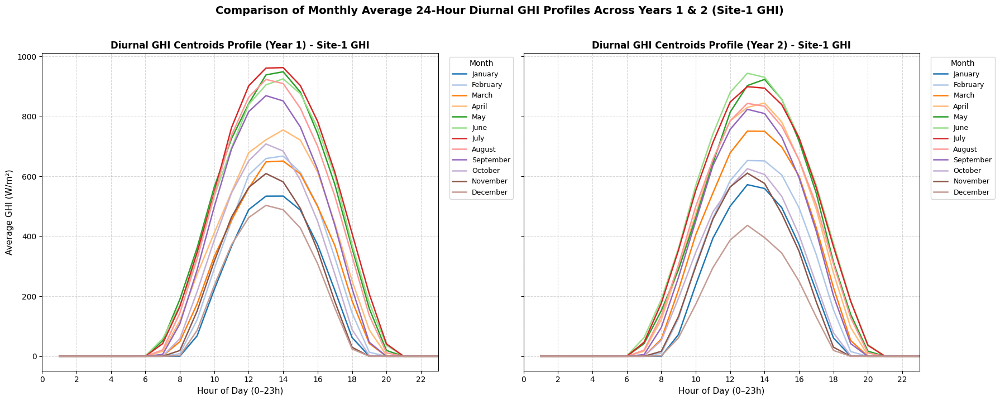

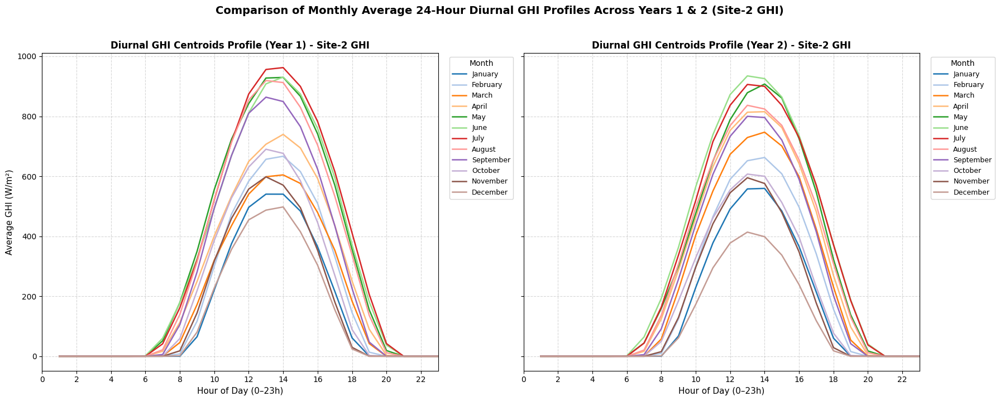

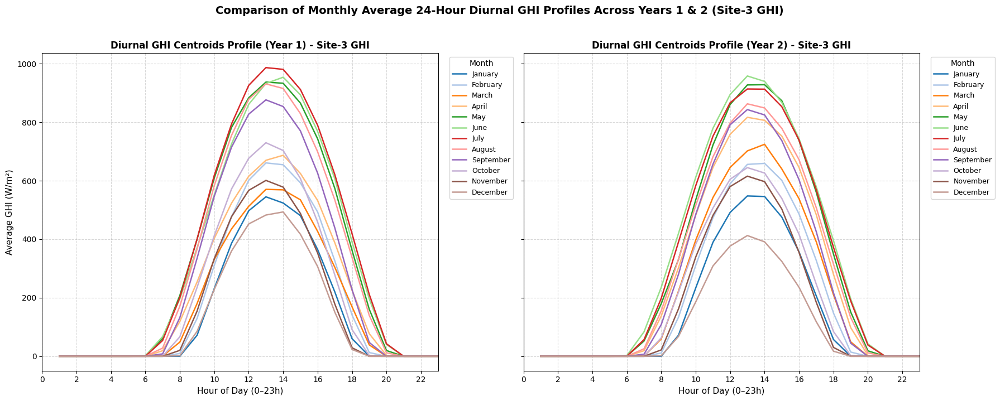

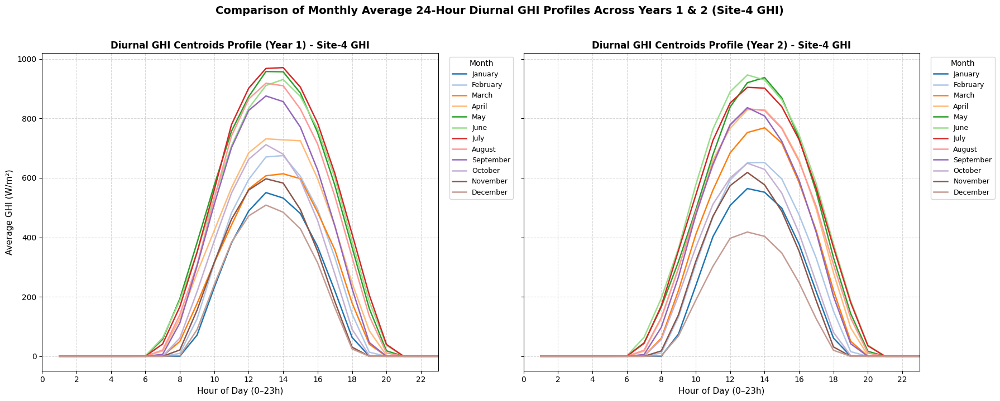

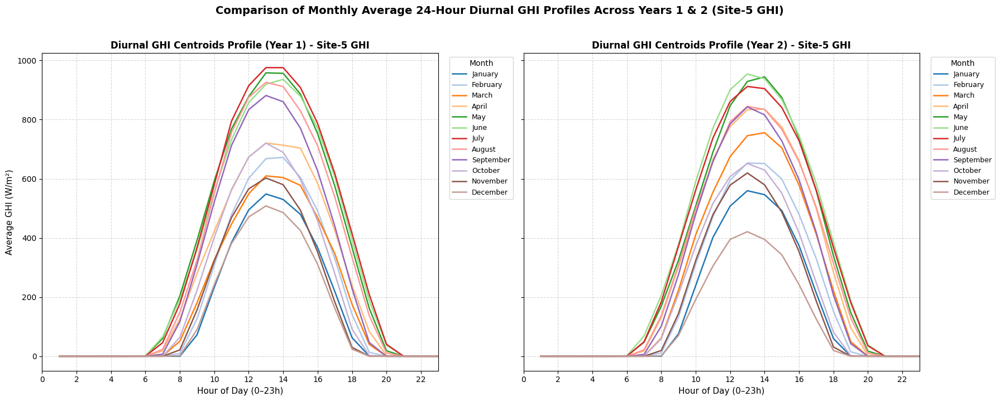

In [16]:
def plot_monthly_ghi_centroids(site):
    # 1. Tính trung bình GHI 24h theo từng Tháng & Năm cho site được chọn
    monthly_centroids = (
        df_train.groupby(['Year', 'Month', 'Hour'])[site]
        .mean()
        .reset_index()
    )

    # 2. Khởi tạo biểu đồ 2 subplots cho Year 1 và Year 2
    fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=True)

    # Bảng màu 12 sắc thái để phân biệt 12 tháng
    colors = plt.cm.tab20(range(12))

    for idx, year in enumerate([1, 2]):
        ax = axes[idx]
        year_data = monthly_centroids[monthly_centroids['Year'] == year]
        
        # Vẽ đường trung bình 24h (diurnal centroid) của từng tháng
        for month in sorted(year_data['Month'].unique()):
            month_data = year_data[year_data['Month'] == month]
            ax.plot(
                month_data['Hour'], 
                month_data[site], 
                label=calendar.month_name[month],
                linewidth=1.8,
                color=colors[month - 1]
            )
        
        # Cấu hình trục X cho 24 giờ (từ 0 đến 23h, bước giãn 2 tiếng)
        ax.set_xticks(range(0, 24, 2))
        ax.set_xlim(0, 23)
        
        ax.set_xlabel("Hour of Day (0–23h)", fontsize=11)
        ax.set_title(f"Diurnal GHI Centroids Profile (Year {year}) - {site}", fontsize=12, fontweight='bold')
        ax.grid(True, linestyle='--', alpha=0.5)
        ax.legend(title="Month", bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)

    # Cấu hình tiêu đề tổng thể
    fig.suptitle(
        f"Comparison of Monthly Average 24-Hour Diurnal GHI Profiles Across Years 1 & 2 ({site})", 
        fontsize=14, 
        fontweight='bold', 
        y=1.02
    )
    axes[0].set_ylabel("Average GHI (W/m²)", fontsize=11)

    plt.tight_layout()
    plt.show()

# Gọi hàm chạy trực tiếp cho site GHI bất kỳ (hoặc site đầu tiên tìm thấy)
site_columns_ghi = [col for col in df_train.columns if "GHI" in col]
for site in site_columns_ghi:
    plot_monthly_ghi_centroids(site)

1. **Standard Symmetric Bell-Shaped Profile (Physical Boundary):**
   - GHI remains at **0 W/m²** from 20:00 to 06:00 the following morning.
   - Solar irradiance begins to increase from **06:00**, reaches its highest value (Peak GHI) around **12:30–13:30**, and drops back to zero after **19:30**.

2. **Distinct Seasonal Patterns:**
   - **Summer Group (May, June, July):** The highest GHI peaks of the year, reaching **950–980 W/m²**. Daylight duration is also the longest, resulting in the widest time window with non-zero solar irradiance.
   - **Transition Group (March, April, August, September):** Peak GHI ranges from approximately **700–880 W/m²**.
   - **Winter Group (November, December, January):** December exhibits the lowest solar irradiance of the year, with peak GHI reaching only around **400–500 W/m²**, approximately half the summer level. Sunrise occurs later (GHI begins to increase at around **07:30**), while sunset occurs earlier (GHI returns to zero at around **18:00**).

3. **Extremely High Spatial Similarity Across the Five Sites (High Spatial Correlation):**
   - The 24-hour profiles of all five sites (Site-1 to Site-5) in both Year 1 and Year 2 are almost **identical** in terms of magnitude, peak timing, and monthly variation patterns.
   - **Implication:** The five measurement stations are located within a relatively small geographic area and are subject to similar regional weather conditions and cloud-cover patterns.

## 5.2 Daily Temperature for 2 years

In [17]:
def plot_daily_variation_temp(month, site):
    fig, axes = plt.subplots(1, 2, figsize=(16, 8), sharey=True)
    for idx, year in enumerate([1, 2]):
        ax = axes[idx]
        filtered_df = df_train[(df_train["Year"] == year) & (df_train["Month"] == month)]
        for day in sorted(filtered_df["Day"].unique()):
            subset = filtered_df[filtered_df["Day"] == day]
            ax.plot(subset["Hour"], subset[site], alpha=0.5, linestyle="-", marker="o", lw=1.0)
        centroid = filtered_df.groupby("Hour")[site].mean()
        ax.plot(centroid.index, centroid, color='black', lw=2.5, marker='D', linestyle='-', label="Centroid")
        ax.set_xlabel("Hour of the Day")
        ax.set_title(f"Hourly Temp for {calendar.month_name[month]} (Year {year}) - {site}")
        ax.legend(loc="upper left")
    axes[0].set_ylabel("Temperature (°C)")
    plt.tight_layout()
    plt.show()

month_widget_temp = widgets.Dropdown(options={calendar.month_name[m]: m for m in sorted(df_train["Month"].unique()) if m != 0}, value=4, description="Month:")
site_columns_temp = [col for col in df_train.columns if "Temp" in col]
site_widget_temp = widgets.Dropdown(options=site_columns_temp, value=site_columns_temp[0], description="Site:")
interact(plot_daily_variation_temp, month=month_widget_temp, site=site_widget_temp)

interactive(children=(Dropdown(description='Month:', index=3, options={'January': np.int64(1), 'February': np.…

<function __main__.plot_daily_variation_temp(month, site)>

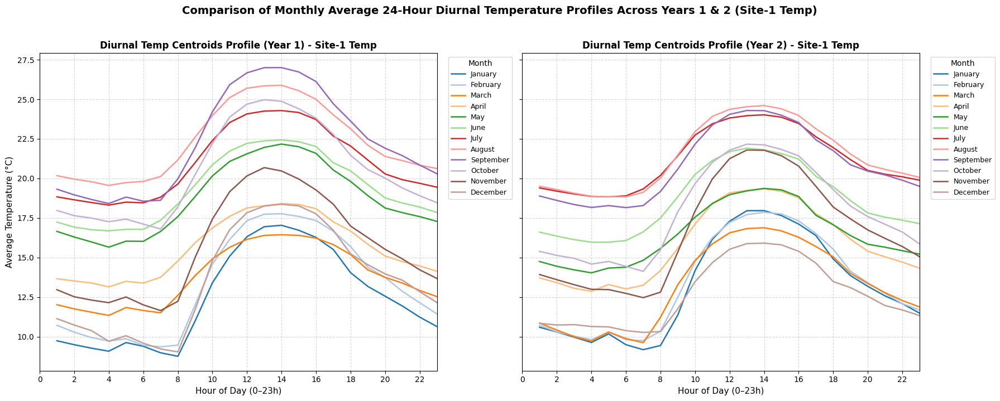

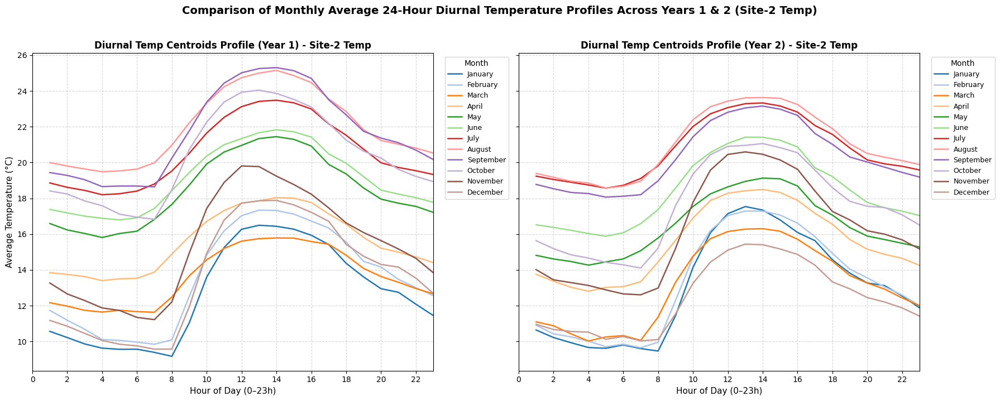

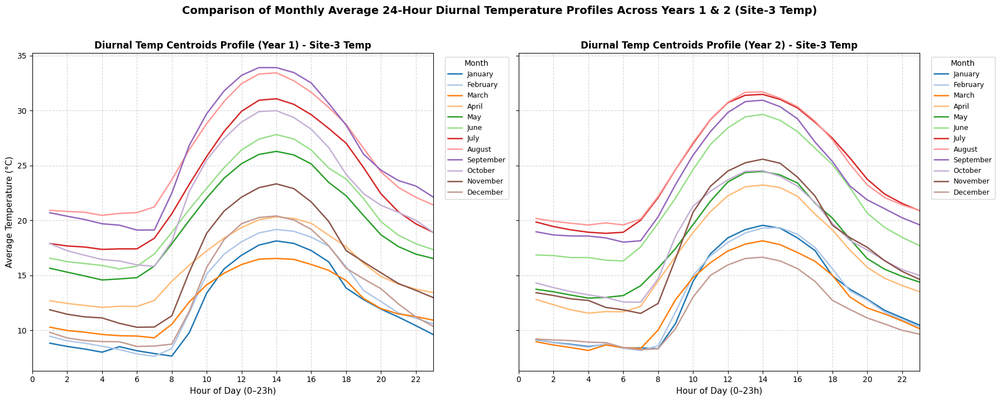

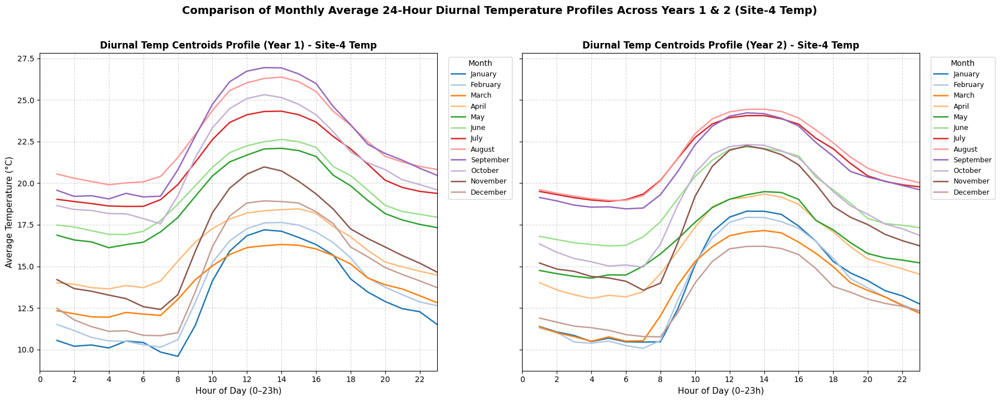

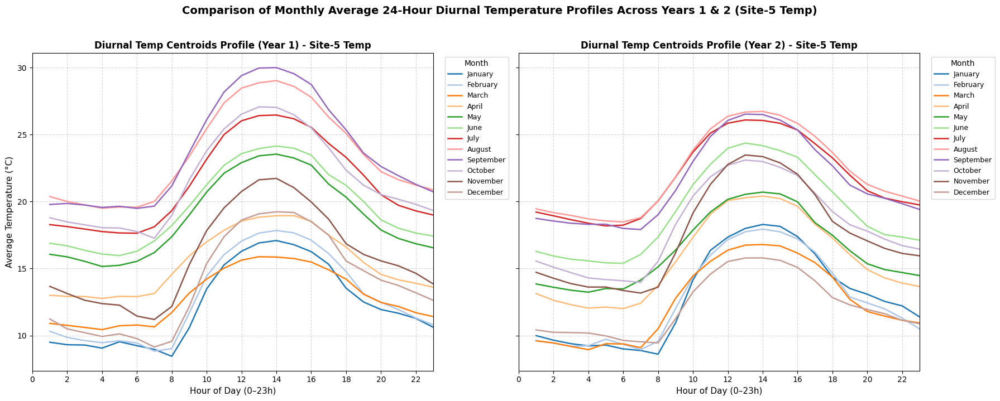

In [18]:
def plot_monthly_temp_centroids(site):
    # 1. Tính trung bình Nhiệt độ (Temperature) 24h theo từng Tháng & Năm cho site được chọn
    monthly_centroids = (
        df_train.groupby(['Year', 'Month', 'Hour'])[site]
        .mean()
        .reset_index()
    )

    # 2. Khởi tạo biểu đồ 2 subplots cho Year 1 và Year 2
    fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=True)

    # Bảng màu 12 sắc thái để phân biệt 12 tháng
    colors = plt.cm.tab20(range(12))

    for idx, year in enumerate([1, 2]):
        ax = axes[idx]
        year_data = monthly_centroids[monthly_centroids['Year'] == year]
        
        # Vẽ đường trung bình 24h (diurnal centroid) của từng tháng
        for month in sorted(year_data['Month'].unique()):
            month_data = year_data[year_data['Month'] == month]
            ax.plot(
                month_data['Hour'], 
                month_data[site], 
                label=calendar.month_name[month],
                linewidth=1.8,
                color=colors[month - 1]
            )
        
        # Cấu hình trục X cho 24 giờ (từ 0 đến 23h, bước giãn 2 tiếng)
        ax.set_xticks(range(0, 24, 2))
        ax.set_xlim(0, 23)
        
        ax.set_xlabel("Hour of Day (0–23h)", fontsize=11)
        ax.set_title(f"Diurnal Temp Centroids Profile (Year {year}) - {site}", fontsize=12, fontweight='bold')
        ax.grid(True, linestyle='--', alpha=0.5)
        ax.legend(title="Month", bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)

    # Cấu hình tiêu đề tổng thể
    fig.suptitle(
        f"Comparison of Monthly Average 24-Hour Diurnal Temperature Profiles Across Years 1 & 2 ({site})", 
        fontsize=14, 
        fontweight='bold', 
        y=1.02
    )
    axes[0].set_ylabel("Average Temperature (°C)", fontsize=11)

    plt.tight_layout()
    plt.show()

# Gọi hàm chạy trực tiếp cho site Temp bất kỳ (hoặc site đầu tiên tìm thấy)
site_columns_temp = [col for col in df_train.columns if "Temp" in col]
for site in site_columns_temp:
    plot_monthly_temp_centroids(site)

- **Fixed Temperature Trough and Peak:**
  - **Temperature Trough (06:00–08:00):** The minimum temperature occurs in the early morning, shortly before or around sunrise (approximately **8–10°C** during the colder months).
  - **Temperature Peak (13:00–15:00):** The maximum temperature is reached during the afternoon, typically between **13:00 and 15:00**.
- **Phase Lag Relative to GHI (Thermal Lag Effect):** While solar irradiance (GHI) reaches its peak around **12:00–13:00**, the temperature peak is delayed by approximately **1–2 hours**, occurring around **13:00–15:00**. This delay represents the time required for the Earth's surface to absorb solar radiation and subsequently transfer heat back to the surrounding air.

**Spatial Heterogeneity and Microclimate Differences Across the Five Sites**

- **Moderate-Temperature Group (Site-1, Site-2, Site-4):**
  - These sites exhibit nearly **identical temperature variation patterns and ranges**.
  - During the summer months (August–September), peak temperatures in Year 1 reach an average of approximately **25.0–27.0°C**, while Year 2 remains around **23.5–24.5°C**.

- **High-Temperature Outlier – Hotspot (Site-3):**
  - Site-3 records the highest temperatures and the strongest day–night temperature variation among the five stations.
  - The summer peak temperature in Year 1 reaches approximately **~34.0°C**, which is **7–9°C higher** than the other sites. In Year 2, the peak remains the highest at approximately **~31.5°C**.
  - *Possible explanation:* Site-3 may be located in an inland area, a valley, or a region experiencing stronger urbanization and heat-retaining effects from concrete and built-up surfaces.

- **Intermediate Site (Site-5):**
  - Temperature levels at Site-5 fall between the moderate-temperature group and Site-3. The summer peak reaches approximately **~30.0°C** in Year 1 and **~26.5–27.0°C** in Year 2.

**Year-over-Year Variation (YoY Trend: Year 1 vs. Year 2)**

- **Cooler Summer Conditions in Year 2:** Peak temperatures during the hottest months (July, August, and September) decrease noticeably by approximately **2.0–3.0°C** across all five sites in Year 2 compared with Year 1. This directly supports the observation from the load analysis that *peak electricity demand in Year 2 is slightly compressed compared with Year 1, potentially due to less extreme weather conditions*.
- **Stable Winter Temperature Baseline:** The nighttime minimum temperatures during the colder months (December, January, and February) remain relatively stable between Year 1 and Year 2, at approximately **8.0–10.0°C**.

## 5.4 Weekly GHI for 2 years

In [20]:
def plot_weekly_comparison(month, site):
    fig, axes = plt.subplots(1, 2, figsize=(18, 8), sharey=True)
    
    for idx, year in enumerate([1, 2]):
        ax = axes[idx]
        
        # Filter for the selected year and month
        month_df = df_train[(df_train["Year"] == year) & (df_train["Month"] == month)]
        
        # Create the 'HourOfWeek' column for a continuous x-axis
        month_df = month_df.copy()
        month_df['HourOfWeek'] = month_df['DayOfWeek'] * 24 + month_df['Hour']
        
        # Find all the unique weeks within that month
        weeks_in_month = month_df['WeekOfYear'].unique()
        
        # Plot each individual week's pattern with transparency
        for week in weeks_in_month:
            week_subset = month_df[month_df['WeekOfYear'] == week]
            ax.plot(week_subset['HourOfWeek'], week_subset[site], alpha=0.3, linestyle="-")
            
        # Calculate and plot the centroid (average weekly pattern for the month)
        centroid = month_df.groupby('HourOfWeek')[site].mean()
        ax.plot(centroid.index, centroid, color='black', lw=2.5, linestyle='-', label="Monthly Centroid")
        
        # --- Formatting the plot ---
        ax.set_xlabel("Hour of the Week")
        ax.set_title(f"Weekly GHI Variation in {calendar.month_name[month]} (Year {year}) - {site}")
        ax.legend(loc="upper left")
        ax.grid(True, linestyle='--', alpha=0.6)
        
        # Set x-ticks to correspond to the start of each day for readability
        tick_locations = [i * 24 for i in range(7)]
        tick_labels = ['Mon', 'Tues', 'Wed', 'Thurs', 'Fri', 'Sat', 'Sun']
        ax.set_xticks(tick_locations)
        ax.set_xticklabels(tick_labels)
        ax.set_xlim(0, 168)

    axes[0].set_ylabel("GHI (W/m$^2$)")
    plt.tight_layout()
    plt.show()

# --- Widgets (reusing your original ones) ---
month_widget_ghi = widgets.Dropdown(options={calendar.month_name[m]: m for m in sorted(df_train["Month"].unique()) if m != 0}, value=4, description="Month:")
site_columns_ghi = [col for col in df_train.columns if "GHI" in col]
site_widget_ghi = widgets.Dropdown(options=site_columns_ghi, value=site_columns_ghi[0], description="Site:")

interact(plot_weekly_comparison, month=month_widget_ghi, site=site_widget_ghi)

interactive(children=(Dropdown(description='Month:', index=3, options={'January': np.int64(1), 'February': np.…

<function __main__.plot_weekly_comparison(month, site)>

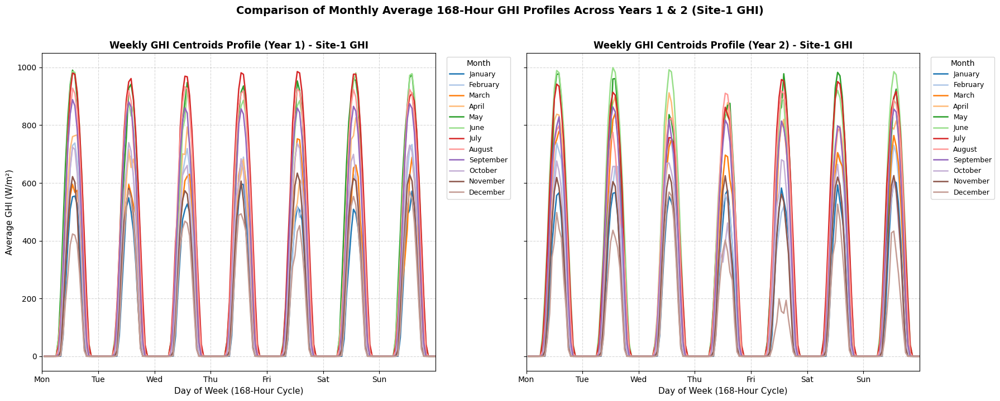

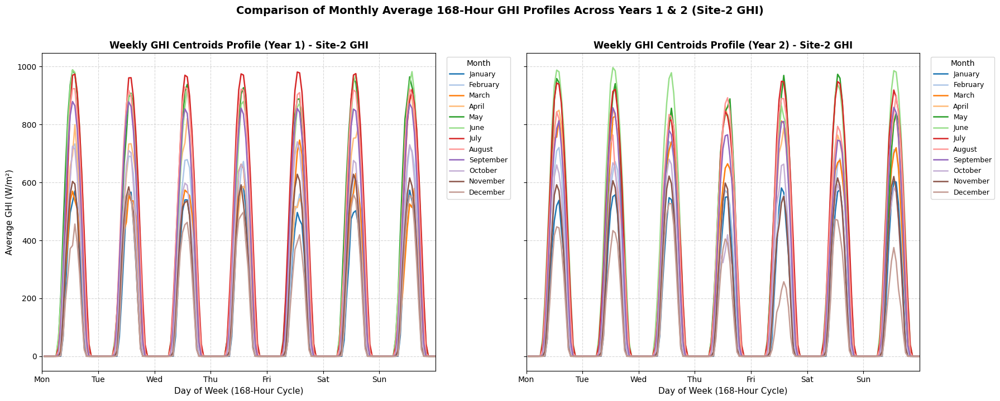

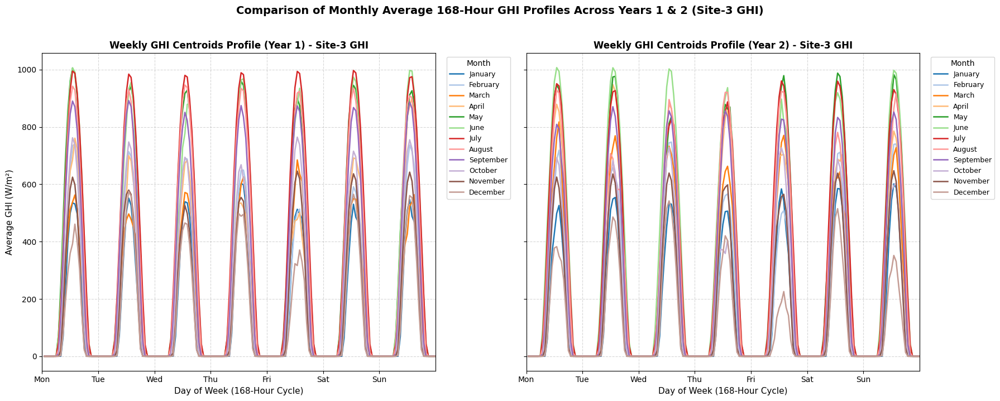

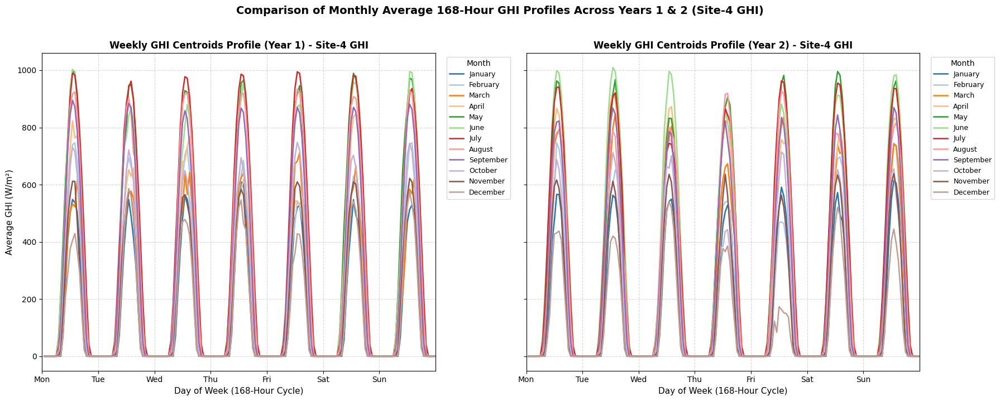

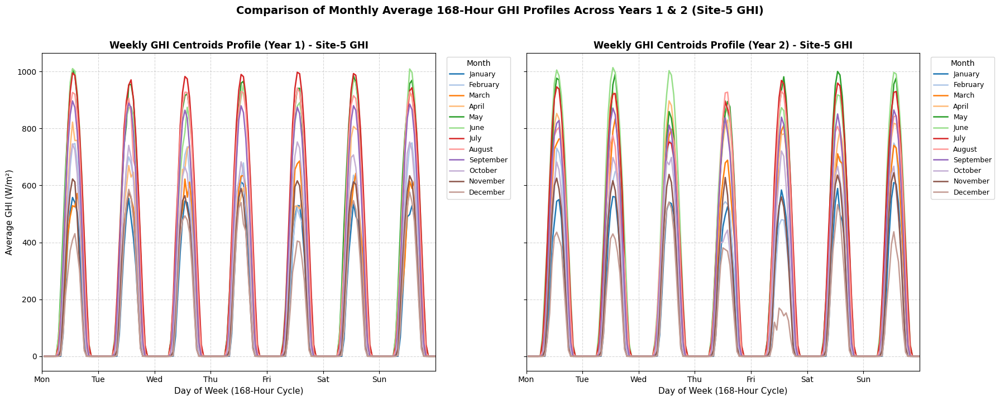

In [21]:
def plot_monthly_weekly_centroids_ghi(site):
    # 1. Tính toán HourOfWeek (0–167) và lấy trung bình GHI theo từng Tháng & Năm
    df_plot_weekly = df_train.copy()
    if 'HourOfWeek' not in df_plot_weekly.columns:
        df_plot_weekly['HourOfWeek'] = df_plot_weekly['DayOfWeek'] * 24 + df_plot_weekly['Hour']

    monthly_centroids = (
        df_plot_weekly.groupby(['Year', 'Month', 'HourOfWeek'])[site]
        .mean()
        .reset_index()
    )

    # 2. Khởi tạo biểu đồ 2 subplots cho Year 1 và Year 2
    fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=True)

    # Bảng màu 12 sắc thái để phân biệt 12 tháng
    colors = plt.cm.tab20(range(12))

    for idx, year in enumerate([1, 2]):
        ax = axes[idx]
        year_data = monthly_centroids[monthly_centroids['Year'] == year]
        
        # Vẽ đường trung bình 168h của từng tháng
        for month in sorted(year_data['Month'].unique()):
            month_data = year_data[year_data['Month'] == month]
            ax.plot(
                month_data['HourOfWeek'], 
                month_data[site], 
                label=calendar.month_name[month],
                linewidth=1.8,
                color=colors[month - 1]
            )
        
        # Cấu hình trục X tương ứng với 7 ngày trong tuần
        tick_locations = [i * 24 for i in range(7)]
        tick_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
        ax.set_xticks(tick_locations)
        ax.set_xticklabels(tick_labels)
        ax.set_xlim(0, 168)
        
        ax.set_xlabel("Day of Week (168-Hour Cycle)", fontsize=11)
        ax.set_title(f"Weekly GHI Centroids Profile (Year {year}) - {site}", fontsize=12, fontweight='bold')
        ax.grid(True, linestyle='--', alpha=0.5)
        ax.legend(title="Month", bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)

    # Cấu hình tiêu đề tổng thể
    fig.suptitle(
        f"Comparison of Monthly Average 168-Hour GHI Profiles Across Years 1 & 2 ({site})", 
        fontsize=14, 
        fontweight='bold', 
        y=1.02
    )
    axes[0].set_ylabel("Average GHI (W/m²)", fontsize=11)

    plt.tight_layout()
    plt.show()

# Gọi hàm chạy trực tiếp cho site GHI đầu tiên
site_columns_ghi = [col for col in df_train.columns if "GHI" in col]
for site in site_columns_ghi:
    plot_monthly_weekly_centroids_ghi(site)

**168-Hour Cyclic Pattern (Weekly Dynamics)**

- **Completely Independent of the Day of the Week:** Unlike electricity load, which is influenced by working schedules, solar irradiance (GHI) is a natural phenomenon. The magnitude and peak GHI across all seven days from Monday to Sunday (`Mon`–`Sun`) within the same month are nearly **identical**.

- **Monthly Variation in Peak Magnitude (Monthly Peak Shift):**
  - **Peak Season (May, June, July):** Weekly average irradiance peaks remain consistently very high, reaching approximately **950–1,000 W/m²** across all days.
  - **Transition Season (March, April, August, September):** Peak irradiance ranges from approximately **700–850 W/m²**.
  - **Low-Radiation Season (November, December, January):** Peak irradiance decreases substantially, with December recording the lowest values at approximately **400–500 W/m²**, less than half the summer level.

**Complete Spatial Homogeneity Across the Five Sites**

- **Structural Consistency:** The 168-hour profiles of all five sites (`Site-1 GHI` to `Site-5 GHI`) exhibit nearly identical patterns, including the timing of irradiance increase, sunset, and peak magnitude.
- **Geographical Interpretation:** The five irradiance measurement stations are likely located within a relatively narrow climatic region and are subject to the same solar cycle and similar solar elevation angles.

**Year-over-Year Variation and Anomalies (Year 1 vs. Year 2)**

- **Strong Temporal Consistency:** The monthly variation patterns of solar irradiance in Year 1 and Year 2 are reproduced with high consistency, indicating a stable underlying seasonal cycle.

- **Weather/Data Anomalies in Year 2:**
  - In Year 2, on **Friday (`Fri`)**, the average irradiance profiles for several months—particularly the winter and transition months represented by the gray/purple curves—exhibit unusual drops or fluctuations around the **200 W/m²** level. This pattern can be observed, for example, in the profiles of Site-1, Site-3, Site-4, and Site-5.
  - This may indicate **unusual weather conditions**, such as heavy cloud cover or prolonged rainfall on Fridays during those months, or potentially a **data artifact** caused by measurement noise or sensor-related issues.

## 5.5 Weekly Temperature for 2 years

In [22]:
def plot_weekly_temp_comparison(month, site):
    fig, axes = plt.subplots(1, 2, figsize=(18, 8), sharey=True)
    
    for idx, year in enumerate([1, 2]):
        ax = axes[idx]
        
        # Filter for the selected year and month
        month_df = df_train[(df_train["Year"] == year) & (df_train["Month"] == month)]
        
        # Create the 'HourOfWeek' column for a continuous x-axis
        month_df = month_df.copy()
        month_df['HourOfWeek'] = month_df['DayOfWeek'] * 24 + month_df['Hour']
        
        # Find all the unique weeks within that month
        weeks_in_month = month_df['WeekOfYear'].unique()
        
        # Plot each individual week's pattern with transparency
        for week in weeks_in_month:
            week_subset = month_df[month_df['WeekOfYear'] == week]
            ax.plot(week_subset['HourOfWeek'], week_subset[site], alpha=0.3, linestyle="-")
            
        # Calculate and plot the centroid (average weekly pattern for the month)
        centroid = month_df.groupby('HourOfWeek')[site].mean()
        ax.plot(centroid.index, centroid, color='black', lw=2.5, linestyle='-', label="Monthly Centroid")
        
        # --- Formatting the plot ---
        ax.set_xlabel("Hour of the Week")
        ax.set_title(f"Weekly Temperature Variation in {calendar.month_name[month]} (Year {year}) - {site}")
        ax.legend(loc="upper left")
        ax.grid(True, linestyle='--', alpha=0.6)
        
        # Set x-ticks to correspond to the start of each day for readability
        tick_locations = [i * 24 for i in range(7)]
        tick_labels = ['Mon', 'Tues', 'Wed', 'Thurs', 'Fri', 'Sat', 'Sun']
        ax.set_xticks(tick_locations)
        ax.set_xticklabels(tick_labels)
        ax.set_xlim(0, 168)

    axes[0].set_ylabel("Temperature (°C)")
    plt.tight_layout()
    plt.show()

# --- Widgets for the Temperature plot ---
month_widget_temp = widgets.Dropdown(options={calendar.month_name[m]: m for m in sorted(df_train["Month"].unique()) if m != 0}, value=4, description="Month:")
site_columns_temp = [col for col in df_train.columns if "Temp" in col]
site_widget_temp = widgets.Dropdown(options=site_columns_temp, value=site_columns_temp[0], description="Site:")

interact(plot_weekly_temp_comparison, month=month_widget_temp, site=site_widget_temp)

interactive(children=(Dropdown(description='Month:', index=3, options={'January': np.int64(1), 'February': np.…

<function __main__.plot_weekly_temp_comparison(month, site)>

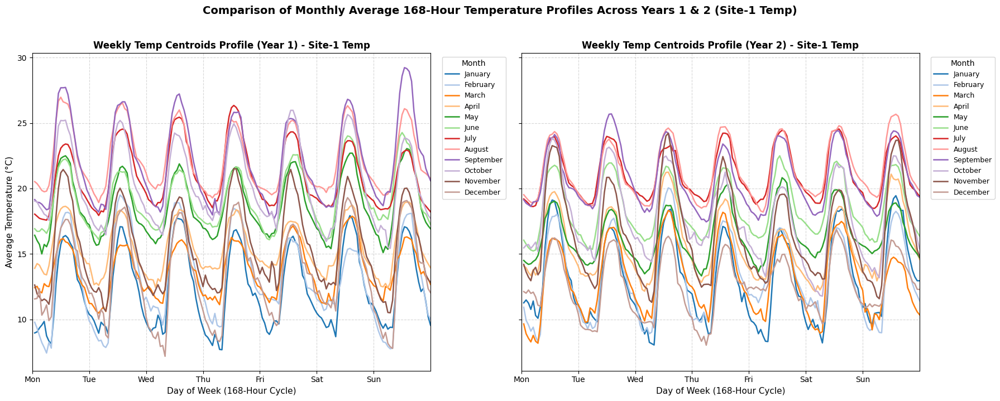

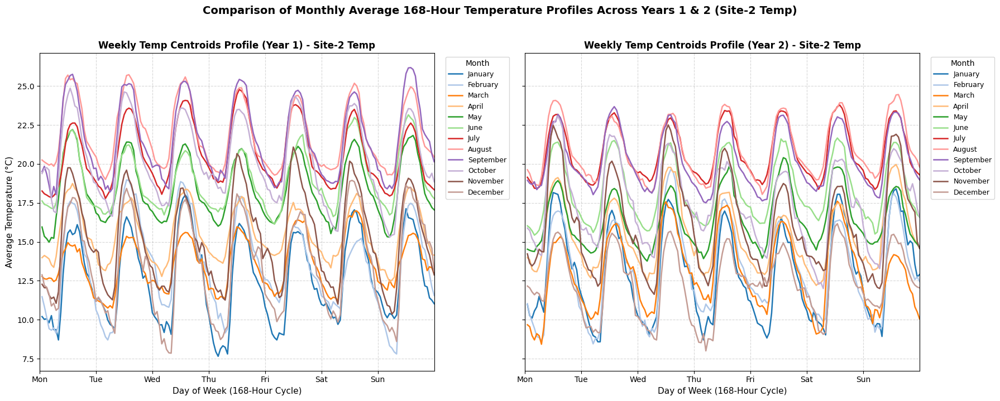

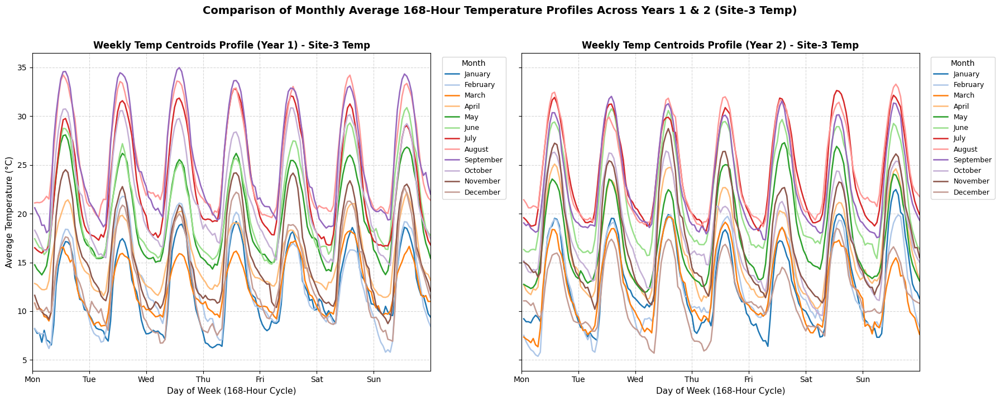

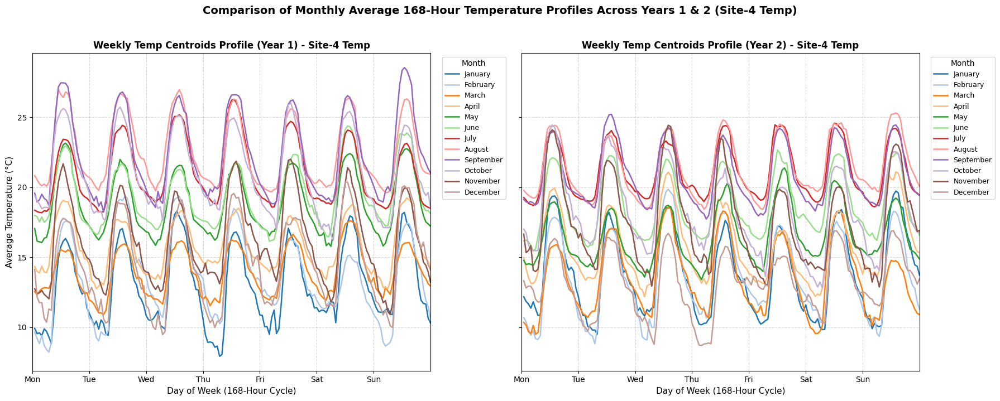

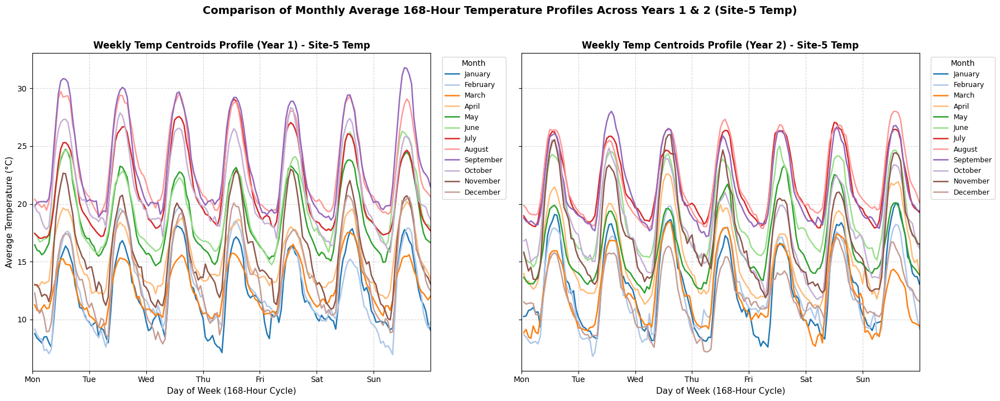

In [23]:
def plot_monthly_weekly_centroids_temp(site):
    # 1. Tính toán HourOfWeek (0–167) và lấy trung bình Nhiệt độ (Temperature) theo từng Tháng & Năm
    df_plot_weekly = df_train.copy()
    if 'HourOfWeek' not in df_plot_weekly.columns:
        df_plot_weekly['HourOfWeek'] = df_plot_weekly['DayOfWeek'] * 24 + df_plot_weekly['Hour']

    monthly_centroids = (
        df_plot_weekly.groupby(['Year', 'Month', 'HourOfWeek'])[site]
        .mean()
        .reset_index()
    )

    # 2. Khởi tạo biểu đồ 2 subplots cho Year 1 và Year 2
    fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=True)

    # Bảng màu 12 sắc thái để phân biệt 12 tháng
    colors = plt.cm.tab20(range(12))

    for idx, year in enumerate([1, 2]):
        ax = axes[idx]
        year_data = monthly_centroids[monthly_centroids['Year'] == year]
        
        # Vẽ đường trung bình 168h của từng tháng
        for month in sorted(year_data['Month'].unique()):
            month_data = year_data[year_data['Month'] == month]
            ax.plot(
                month_data['HourOfWeek'], 
                month_data[site], 
                label=calendar.month_name[month],
                linewidth=1.8,
                color=colors[month - 1]
            )
        
        # Cấu hình trục X tương ứng với 7 ngày trong tuần
        tick_locations = [i * 24 for i in range(7)]
        tick_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
        ax.set_xticks(tick_locations)
        ax.set_xticklabels(tick_labels)
        ax.set_xlim(0, 168)
        
        ax.set_xlabel("Day of Week (168-Hour Cycle)", fontsize=11)
        ax.set_title(f"Weekly Temp Centroids Profile (Year {year}) - {site}", fontsize=12, fontweight='bold')
        ax.grid(True, linestyle='--', alpha=0.5)
        ax.legend(title="Month", bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)

    # Cấu hình tiêu đề tổng thể
    fig.suptitle(
        f"Comparison of Monthly Average 168-Hour Temperature Profiles Across Years 1 & 2 ({site})", 
        fontsize=14, 
        fontweight='bold', 
        y=1.02
    )
    axes[0].set_ylabel("Average Temperature (°C)", fontsize=11)

    plt.tight_layout()
    plt.show()

# Gọi hàm chạy trực tiếp cho site Temp đầu tiên tìm thấy
site_columns_temp = [col for col in df_train.columns if "Temp" in col]
for site in site_columns_temp:
    plot_monthly_weekly_centroids_temp(site)

**168-Hour Periodicity and Random Heatwave Noise (Weekly Weather Artifacts)**

- **Recurring 24-Hour Physical Cycle:** Unlike electricity load, which varies according to work schedules, natural temperature follows a regular daily cycle from Monday to Sunday (`Mon`–`Sun`), with a trough in the early morning (06:00–08:00) and a peak in the early afternoon (13:00–15:00).

- **Heatwave-Induced Noise:** Some months exhibit unusually high temperature peaks on specific days of the week. For example, in Year 1, the September peak on Sunday across Site-1, Site-2, Site-4, and Site-5 reaches approximately **27–29°C**. This is likely the result of a random heatwave coinciding with that particular day rather than a systematic weekly behavioral pattern.

**Microclimate Differentiation Across the Five Sites (Spatial Clustering)**

- **Moderate-Temperature Group (Site-1, Site-2, Site-4):**
  - The temperature profiles and variation ranges are nearly **identical** across these sites.
  - Summer temperature peaks in Year 1 reach approximately **25.0–27.0°C**, with an anomalous increase to **~28.5°C** in September. In Year 2, the peaks decrease to approximately **23.5–25.5°C**.

- **High-Temperature Hotspot (Site-3):**
  - Site-3 consistently records the highest temperatures in the system, with an extremely wide day–night temperature range.
  - Summer temperature peaks reach **34.0–35.0°C** in Year 1 and **32.0–33.0°C** in Year 2. During winter, nighttime temperatures can drop as low as **5.0–7.0°C**.

- **Intermediate Zone (Site-5):**
  - Temperature levels fall between the moderate-temperature group and Site-3. Peak temperatures reach **30.0–31.5°C** in Year 1 and **26.5–28.0°C** in Year 2.

**Year-over-Year Cooling Trend (YoY Shift: Year 1 vs. Year 2)**

- **Year 2 Is Cooler Than Year 1 Across the Entire 168-Hour Profile:**
  - Peak temperatures across all summer/autumn months (June, July, August, and September) decrease consistently by approximately **2.0–3.0°C** in Year 2 compared with Year 1 across all five sites.

- **Stable Winter Temperature Baseline:**
  - Nighttime temperatures during the colder months (December, January, and February) follow a consistent pattern across both years, remaining within approximately **7.0–10.0°C**.

# 6. Correlation Analysis

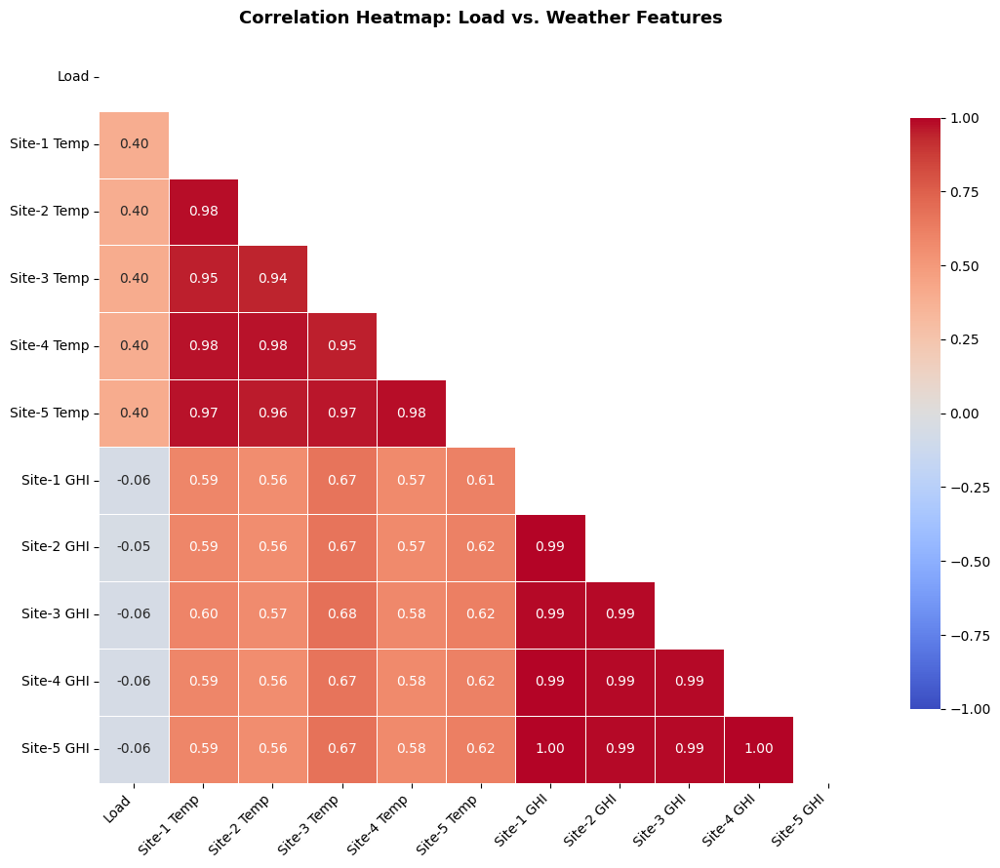

In [29]:
features = [
    'Load', 
    'Site-1 Temp', 'Site-2 Temp', 'Site-3 Temp', 'Site-4 Temp', 'Site-5 Temp',
    'Site-1 GHI', 'Site-2 GHI', 'Site-3 GHI', 'Site-4 GHI', 'Site-5 GHI'
]

# 2. Tính ma trận tương quan Pearson
corr_matrix = df_train[features].corr(method='pearson')

# 3. (Tùy chọn) Tạo Mask để che bớt 1 nửa tam giác trên (tránh lặp thông tin đối xứng)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# 4. Vẽ Heatmap
plt.figure(figsize=(11, 9))

# Main Title
plt.title('Correlation Heatmap: Load vs. Weather Features', fontsize=13, fontweight='bold', pad=15)

sns.heatmap(
    corr_matrix, 
    mask=mask,           # Che nửa tam giác trên giúp chart gọn hơn
    annot=True,          # Hiển thị giá trị hệ số r lên từng ô
    fmt='.2f',           # Làm tròn 2 chữ số thập phân
    cmap='coolwarm',     # Bảng màu: Đỏ (tương quan dương), Xanh (tương quan âm)
    vmin=-1, vmax=1,     # Chuẩn hóa thang đo từ -1 đến 1
    center=0,            # Điểm trung hòa màu sắc là 0
    linewidths=0.5,      # Đường kẻ chia giữa các ô
    cbar_kws={"shrink": 0.8}
)

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

- The correlation between Load and Temp/GHI is low -> we should use models that can learn the non-linear relationship between these variables.

- It appears that there is a high corrleation between each temperature of each Site, the same for GHI -> We should decompose these features into a single representative.

# 7. Multicolinearity Analysis

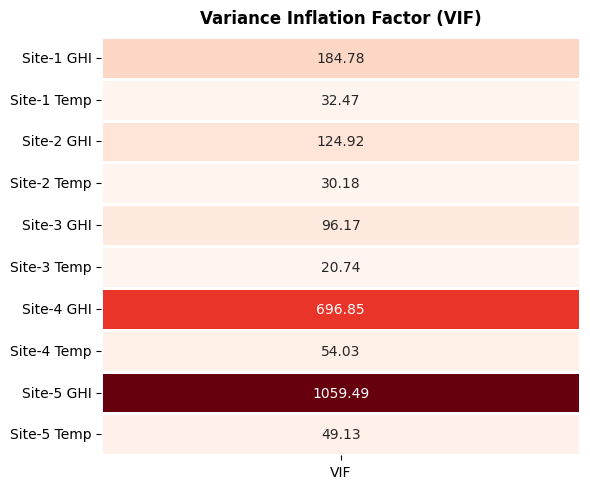

In [30]:
predictor_cols = sorted([col for col in df_train.columns if 'Temp' in col or 'GHI' in col])
predictor_df = df_train[predictor_cols]

vif_data = pd.DataFrame()
vif_data["Variable"] = predictor_df.columns

# Calculate VIF for each variable
vif_data["VIF"] = [variance_inflation_factor(predictor_df.values, i) for i in range(len(predictor_df.columns))]

plt.figure(figsize=(6, len(vif_data) * 0.4 + 1))

# Vẽ heatmap hiển thị chỉ số VIF kèm màu nền Reds
sns.heatmap(
    vif_data.set_index('Variable')[['VIF']], 
    annot=True, 
    fmt=".2f", 
    cmap="Reds", 
    cbar=False,
    linewidths=1,
    linecolor='white'
)

plt.title("Variance Inflation Factor (VIF)", fontsize=12, fontweight='bold', pad=10)
plt.ylabel("")
plt.tight_layout()

# Lưu file ảnh
plt.savefig("../report/vif_analysis.png", dpi=300, bbox_inches='tight')
plt.show()